In [1]:
!pip install -q decord albumentations timm tensorboard opencv-python

In [2]:
import os, cv2, numpy as np
from tqdm import tqdm
from decord import VideoReader, cpu

VIDEO_ROOT = "/home/Major_project_dataset"
OUT_ROOT   = "/home/dataset_faces"
NUM_FRAMES = 12
IMG_SIZE   = 224

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def sample_frames(video_path):
    vr = VideoReader(video_path, ctx=cpu(0))
    idxs = np.linspace(0, len(vr)-1, NUM_FRAMES).astype(int)
    return vr.get_batch(idxs).asnumpy()

def crop_face(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(gray, 1.3, 5)

    if len(faces) > 0:
        x,y,w,h = faces[0]
        frame = frame[y:y+h, x:x+w]

    return cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

def process_video(video_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    frames = sample_frames(video_path)

    for i,f in enumerate(frames):
        face = crop_face(f)
        cv2.imwrite(f"{out_dir}/{i}.jpg", face)

In [4]:
def load_ids(path):
    with open(path) as f:
        return set(x.strip() for x in f.readlines())

train_ids = load_ids("/home/Major_project_dataset/splits/train_identities.txt")
val_ids   = load_ids("/home/Major_project_dataset/splits/val_identities.txt")
test_ids  = load_ids("/home/Major_project_dataset/splits/test_identities.txt")

In [5]:
from glob import glob

def collect_videos():
    samples = []

    # REAL
    for vid in glob("/home/Major_project_dataset/real/**/*.mp4", recursive=True):
        identity = vid.split("/")[-4]
        samples.append((vid, "real", identity))

    # FAKE
    for vid in glob("/home/Major_project_dataset/fake/**/*.mp4", recursive=True):
        identity = vid.split("/")[-2]
        samples.append((vid, "fake", identity))

    return samples

samples = collect_videos()
len(samples)

11605

In [6]:
def split_samples(samples):
    train,val,test = [],[],[]
    for path,label,identity in samples:
        if identity in train_ids:
            train.append((path,label))
        elif identity in val_ids:
            val.append((path,label))
        elif identity in test_ids:
            test.append((path,label))
    return train,val,test

train_samples, val_samples, test_samples = split_samples(samples)

In [7]:
def process_split(samples, split):
    for path,label in tqdm(samples):
        name = os.path.basename(path).replace(".mp4","")
        out_dir = f"{OUT_ROOT}/{split}/{label}/{name}"
        process_video(path, out_dir)

process_split(train_samples,"train")
process_split(val_samples,"val")
process_split(test_samples,"test")

100%|██████████| 373/373 [03:00<00:00,  2.07it/s]


In [8]:
import torch, timm, albumentations as A
from torch.utils.data import Dataset, DataLoader
import cv2, numpy as np, os
from glob import glob

class CFG:
    img_size=224
    batch_size=32
    epochs=8
    lr=3e-4
    num_workers=4
    device="cuda"

cfg=CFG()

In [9]:
train_tfms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(p=0.5),
    A.GaussianBlur(p=0.2),
    A.GaussNoise(p=0.2),
    A.ImageCompression(quality_lower=30,quality_upper=100,p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Resize(224,224)
])

val_tfms = A.Compose([A.Resize(224,224)])

/tmp/ipykernel_2728/3045746285.py:6: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=30,quality_upper=100,p=0.5),


In [10]:
class FaceDataset(Dataset):
    def __init__(self, split, train=True):
        self.paths = glob(f"/home/dataset_faces/{split}/**/*.jpg",recursive=True)
        self.train=train
        
    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        path=self.paths[i]
        img=cv2.imread(path)
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        if self.train: img=train_tfms(image=img)["image"]
        else: img=val_tfms(image=img)["image"]

        img=torch.tensor(img).permute(2,0,1)/255.0
        label=1 if "/fake/" in path else 0
        return img.float(), torch.tensor(label).float()

In [11]:
train_loader = DataLoader(FaceDataset("train",True),
                          batch_size=cfg.batch_size,shuffle=True,
                          num_workers=cfg.num_workers)

val_loader   = DataLoader(FaceDataset("val",False),
                          batch_size=cfg.batch_size,shuffle=False,
                          num_workers=cfg.num_workers)

In [12]:
model = timm.create_model("convnext_tiny", pretrained=True, num_classes=1)
model.cuda()

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)


In [13]:
 from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import torch.nn.functional as F

opt=torch.optim.AdamW(model.parameters(),lr=cfg.lr)
best_auc=0

for epoch in range(cfg.epochs):
    model.train()
    for x,y in tqdm(train_loader):
        x,y=x.cuda(),y.cuda()
        pred=model(x).squeeze()
        loss=F.binary_cross_entropy_with_logits(pred,y)

        opt.zero_grad()
        loss.backward()
        opt.step()

    # validation
    model.eval()
    preds,labels=[],[]
    with torch.no_grad():
        for x,y in val_loader:
            p=torch.sigmoid(model(x.cuda()).squeeze()).cpu()
            preds+=p.tolist(); labels+=y.tolist()

    auc=roc_auc_score(labels,preds)
    print("Epoch",epoch,"AUC",auc)

    if auc>best_auc:
        best_auc=auc
        torch.save(model.state_dict(),"best_model.pt")

100%|██████████| 87/87 [00:08<00:00,  9.92it/s]


Epoch 0 AUC 0.8526372354497356


100%|██████████| 87/87 [00:08<00:00, 10.39it/s]


Epoch 1 AUC 0.9881365740740741


100%|██████████| 87/87 [00:08<00:00, 10.25it/s]


...

Epoch 5 AUC 0.988250248015873


100%|██████████| 87/87 [00:08<00:00,  9.91it/s]


Epoch 6 AUC 0.995980076058201


100%|██████████| 87/87 [00:08<00:00,  9.78it/s]


Epoch 7 AUC 0.9995659722222222


In [15]:
def predict_video(video_path):
    model.eval()
    frames=sample_frames(video_path)
    scores=[]
    for f in frames:
        face=crop_face(f)
        face=torch.tensor(face).permute(2,0,1).unsqueeze(0)/255.0
        score=torch.sigmoid(model(face.cuda())).item()
        scores.append(score)
    return np.mean(scores)

In [16]:
!pip install -q seaborn matplotlib scikit-learn

In [17]:
import torch, timm

model = timm.create_model("convnext_tiny", pretrained=False, num_classes=1)
model.load_state_dict(torch.load("best_model.pt", map_location="cuda"))
model.cuda()
model.eval()

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)


In [18]:
test_loader = DataLoader(
    FaceDataset("test", train=False),
    batch_size=32,
    shuffle=False,
    num_workers=4
)

In [19]:
from tqdm import tqdm
import numpy as np

all_probs = []
all_labels = []

with torch.no_grad():
    for x,y in tqdm(test_loader):
        x = x.cuda()
        logits = model(x).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs.tolist())
        all_labels.extend(y.numpy().tolist())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

100%|██████████| 20/20 [00:00<00:00, 24.13it/s]


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pred_labels = (all_probs >= 0.5).astype(int)

acc  = accuracy_score(all_labels, pred_labels)
prec = precision_score(all_labels, pred_labels)
rec  = recall_score(all_labels, pred_labels)
f1   = f1_score(all_labels, pred_labels)
auc  = roc_auc_score(all_labels, all_probs)

print("Test Accuracy :", acc)
print("Precision     :", prec)
print("Recall        :", rec)
print("F1 Score      :", f1)
print("ROC-AUC       :", auc)

Test Accuracy : 0.9575471698113207
Precision     : 0.9385749385749386
Recall        : 0.9947916666666666
F1 Score      : 0.965865992414665
ROC-AUC       : 0.9817501653439153


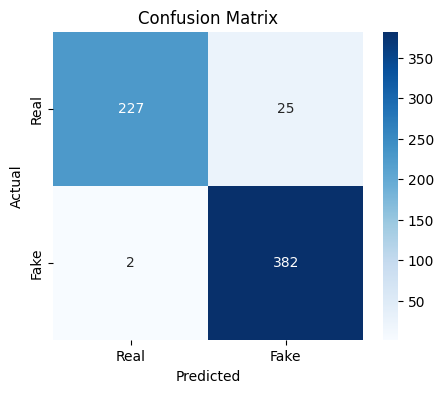

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, pred_labels)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Fake"],
            yticklabels=["Real","Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

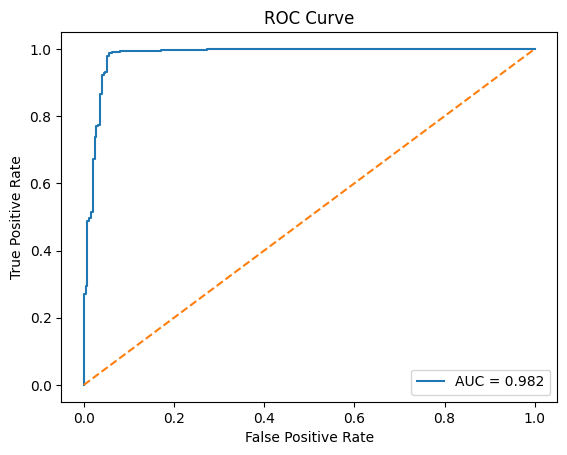

In [22]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
